#### **Assignment 2: Clustering and Kernels**

**Members: Cui(Cathy) Yu, Shravani Mahadeshwar, Priya Botsa, Marc Hayes, Shaonan Feng and Di Yang**

- *Course: Machine Learning 2*
- *Prof: Jan Nagler*
- *Due: 25 April 2026*

**1. Cluster the Clustering Monster**

Modify the provided clustering code to work on your own dataset. Apply
at least two clustering methods (e.g. k-means and one other), adjust their
parameters, visualize the results, and briefly compare which method works
best for your data and why.

**Importing necessary libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import cluster
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.optimize import linear_sum_assignment
from sklearn.mixture import GaussianMixture
from matplotlib.patches import Ellipse
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)


**Loading the dataset**

In [2]:
col_names = ['area', 'perimeter', 'compactness', 'length_kernel',
             'width_kernel', 'asymmetry_coeff', 'length_groove', 'target']
df = pd.read_csv('data/seeds_dataset.txt', sep='\s+', header=None, names=col_names)
y_true = df['target']
X_raw = df.drop(columns=['target'])
print("Shape:", X_raw.shape)
print("Classes:", y_true.unique())
X_raw.head()

Shape: (210, 7)
Classes: [1 2 3]


,area,perimeter,compactness,length_kernel,width_kernel,asymmetry_coeff,length_groove
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175


In [3]:
print("Missing values:", X_raw.isnull().sum().sum())

Missing values: 0


**Scaling the features**

In [4]:
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
print("Scaled shape:", X.shape)

Scaled shape: (210, 7)


**Plotting the first two principal components to visualize the data distribution**

Variance explained by PC1+PC2: 88.98%


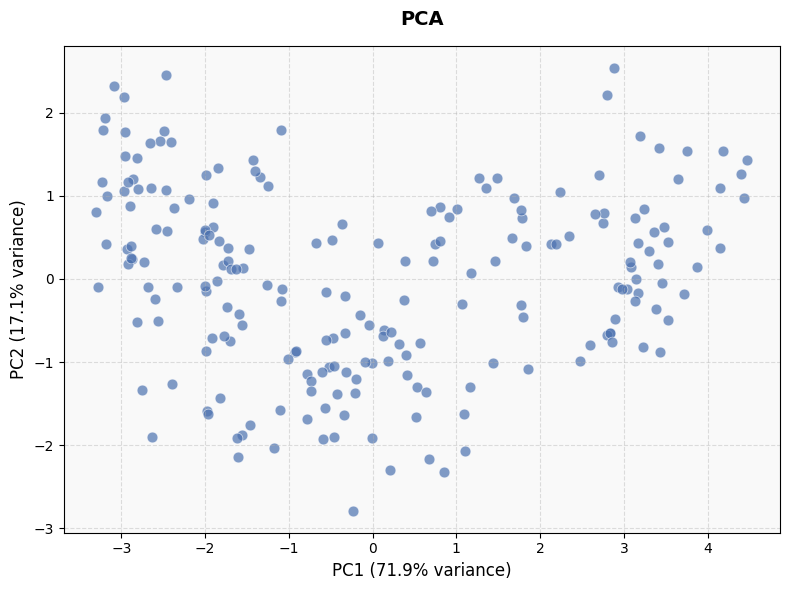

In [5]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
var_explained = pca.explained_variance_ratio_.sum()
print(f"Variance explained by PC1+PC2: {var_explained:.2%}")
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_pca[:, 0], X_pca[:, 1], s=60, alpha=0.7,
           color='#4C72B0', edgecolors='white', linewidths=0.5)
ax.set_title('PCA', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_facecolor('#f9f9f9')
fig.tight_layout()
plt.show()

**Elbow and Silhouette: Plotting inertia and silhouette scores for K=2 to 10 for hypperparameter tuning**

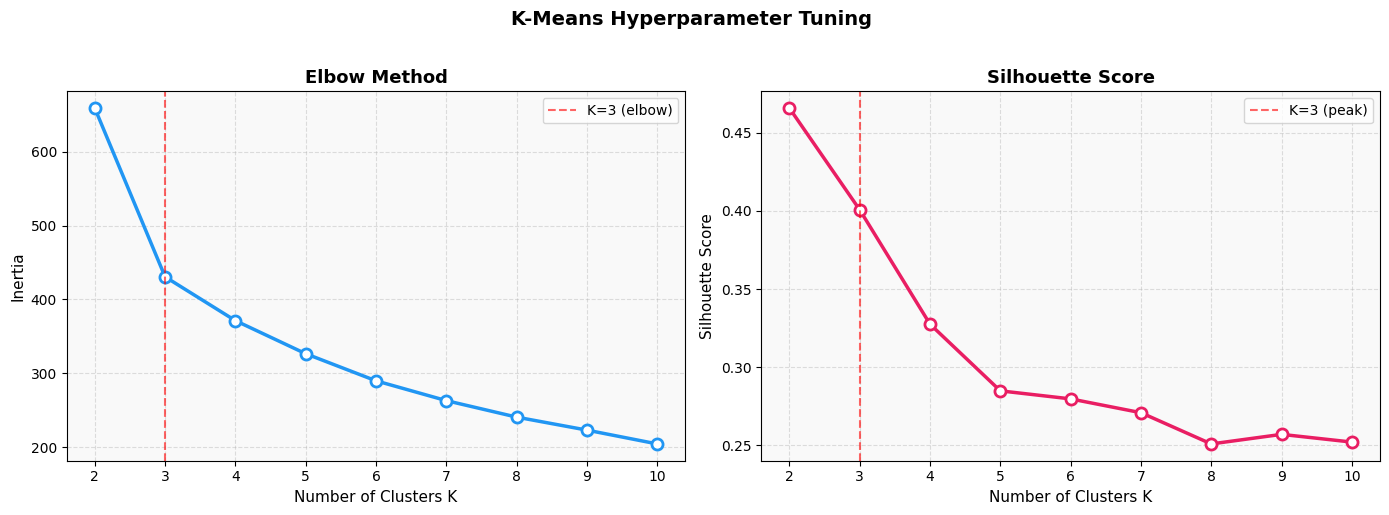

Chosen K = 3


In [6]:
inertias, silhouettes = [], []
K_range = range(2, 11)
for k in K_range:
    km = cluster.KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, km.labels_))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('K-Means Hyperparameter Tuning ',
             fontsize=14, fontweight='bold', y=1.02)
# Elbow
axes[0].plot(K_range, inertias, 'o-', color='#2196F3',
             linewidth=2.5, markersize=8, markerfacecolor='white',
             markeredgewidth=2)
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.6, label='K=3 (elbow)')
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters K', fontsize=11)
axes[0].set_ylabel('Inertia', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.4)
axes[0].set_facecolor('#f9f9f9')
# Silhouette
axes[1].plot(K_range, silhouettes, 'o-', color='#E91E63',
             linewidth=2.5, markersize=8, markerfacecolor='white',
             markeredgewidth=2)
axes[1].axvline(x=3, color='red', linestyle='--', alpha=0.6, label='K=3 (peak)')
axes[1].set_title('Silhouette Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters K', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.4)
axes[1].set_facecolor('#f9f9f9')
fig.tight_layout()
plt.show()
best_k = 3
print(f"Chosen K = {best_k}")

In [7]:
# Creating a mapping function to align cluster labels with true labels
def align_labels(ref, new, n):
    """Aligning new cluster labels to reference labels via Hungarian algorithm."""
    cost = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            cost[i, j] = -np.sum((ref == i) & (new == j))
    _, col_ind = linear_sum_assignment(cost)
    return col_ind, col_ind[new]
def draw_ellipse(mean, cov, ax, color, pca, alpha=0.15, n_std=2.0):
    """Drawing a confidence ellipse for a GMM component in PCA space."""
    cov_pca = pca.components_ @ cov @ pca.components_.T
    vals, vecs = np.linalg.eigh(cov_pca)
    angle = np.degrees(np.arctan2(*vecs[:, -1][::-1]))
    width, height = 2 * n_std * np.sqrt(vals[::-1])
    ax.add_patch(Ellipse(xy=mean, width=width, height=height,
                         angle=angle, color=color, alpha=alpha))
    ax.add_patch(Ellipse(xy=mean, width=width, height=height,
                         angle=angle, fill=False,
                         edgecolor=color, linewidth=2, linestyle='--'))
palette = ['#E63946', '#2A9D8F', '#E9C46A']
cluster_names = ['Kama', 'Rosa', 'Canadian']

**KMeans**

In [8]:
kmeans = cluster.KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans.fit(X)
labels_km = kmeans.labels_

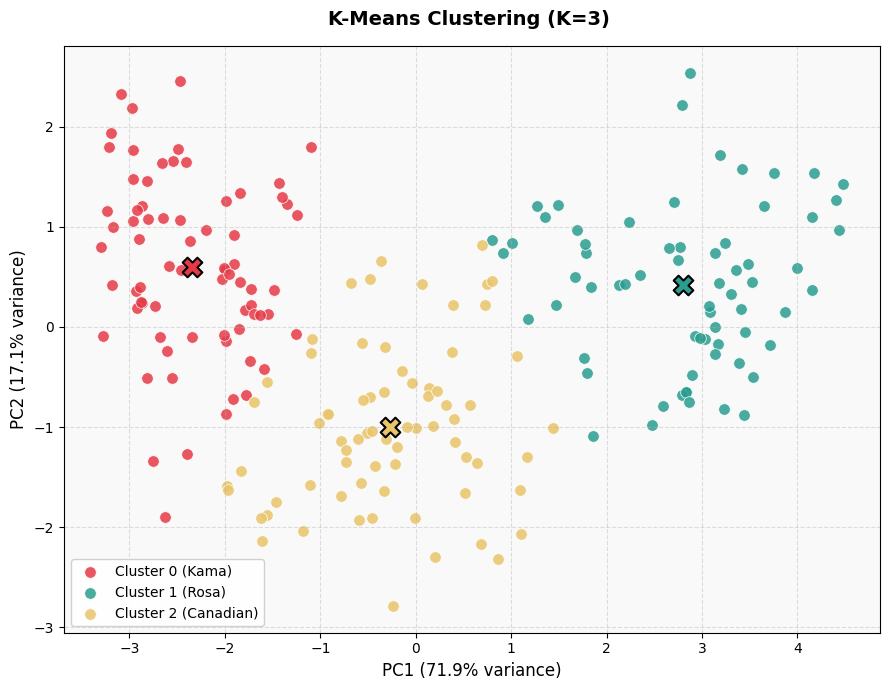

In [9]:
centers_pca = pca.transform(kmeans.cluster_centers_)
fig, ax = plt.subplots(figsize=(9, 7))
for i in range(best_k):
    mask = labels_km == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               s=70, alpha=0.85, color=palette[i],
               edgecolors='white', linewidths=0.6,
               label=f'Cluster {i} ({cluster_names[i]})')
    ax.scatter(*centers_pca[i], s=200, color=palette[i],  
               marker='X', edgecolors='black', linewidths=1.5, zorder=5)
ax.set_title(f'K-Means Clustering (K={best_k}) ',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_facecolor('#f9f9f9')
fig.tight_layout()
plt.show()

**Gaussian Mixture Models**

In [10]:
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(X)
labels_gmm = gmm.predict(X)
probs = gmm.predict_proba(X)  
print(f"GMM converged: {gmm.converged_}")
print(f"GMM BIC: {gmm.bic(X):.2f}")  
print(f"GMM AIC: {gmm.aic(X):.2f}")
col_ind, labels_gmm_aligned = align_labels(labels_km, labels_gmm, best_k)
gmm_means_aligned = gmm.means_[col_ind]
gmm_covs_aligned = gmm.covariances_[col_ind]


GMM converged: True
GMM BIC: -69.70
GMM AIC: -427.84



Cluster mean profiles:


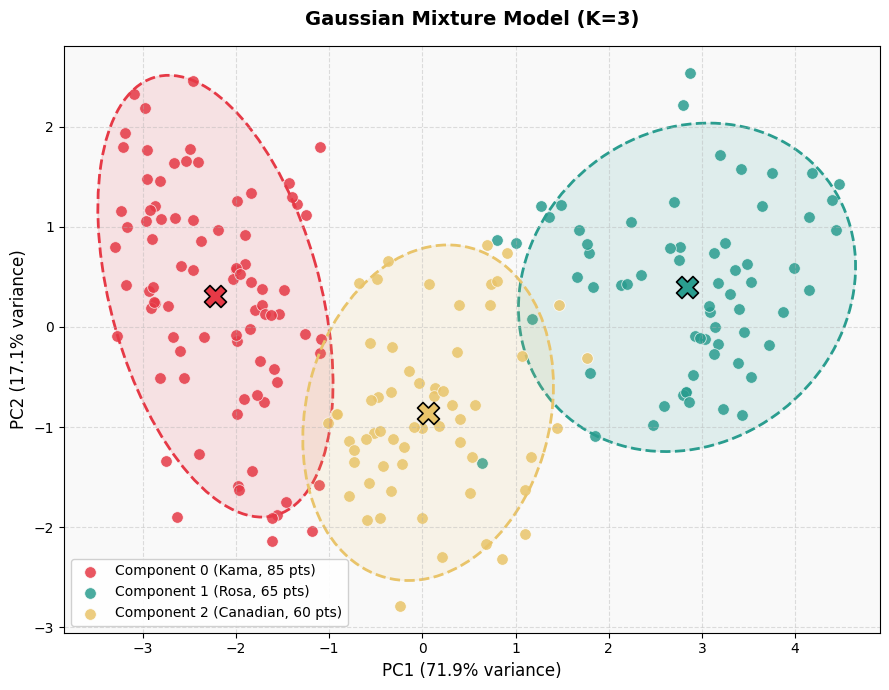

In [11]:
X_df = X_raw.copy()
X_df['cluster'] = labels_km
print("\nCluster mean profiles:")
X_df.groupby('cluster').mean().round(3)
means_pca = pca.transform(gmm_means_aligned)
fig, ax = plt.subplots(figsize=(9, 7))
for i in range(best_k):
    mask = labels_gmm_aligned == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               s=70, alpha=0.85, color=palette[i],
               edgecolors='white', linewidths=0.6,
               label=f'Component {i} ({cluster_names[i]}, {mask.sum()} pts)')
    draw_ellipse(means_pca[i], gmm_covs_aligned[i], ax, palette[i], pca, alpha=0.12)
    ax.scatter(*means_pca[i], s=250, color=palette[i],
               marker='X', edgecolors='black', linewidths=1.2, zorder=5)
ax.set_title('Gaussian Mixture Model (K=3)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_facecolor('#f9f9f9')
fig.tight_layout()
plt.show()

**Comparing both the clustering algos**

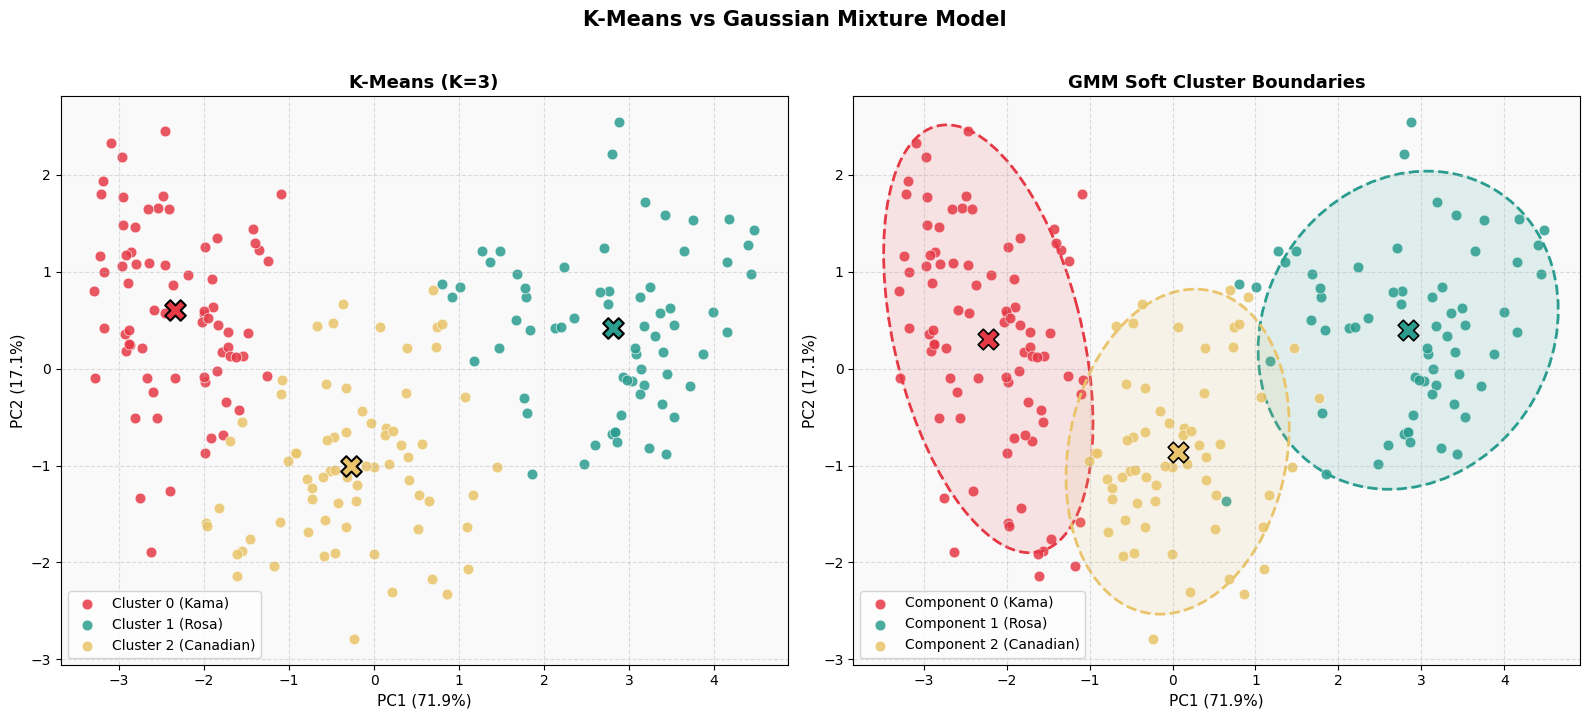

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('K-Means vs Gaussian Mixture Model',
             fontsize=15, fontweight='bold', y=1.02)
for i in range(best_k):
    mask_km = labels_km == i
    axes[0].scatter(
        X_pca[mask_km, 0], X_pca[mask_km, 1],
        s=60, alpha=0.85, color=palette[i],
        edgecolors='white', linewidths=0.5,
        label=f'Cluster {i} ({cluster_names[i]})')
    axes[0].scatter(
        centers_pca[i, 0], centers_pca[i, 1],
        s=220, color=palette[i], marker='X',
        edgecolors='black', linewidths=1.5, zorder=5)
    mask_gmm = labels_gmm_aligned == i
    axes[1].scatter(
        X_pca[mask_gmm, 0], X_pca[mask_gmm, 1],
        s=60, alpha=0.85, color=palette[i],
        edgecolors='white', linewidths=0.5,
        label=f'Component {i} ({cluster_names[i]})')
    draw_ellipse(means_pca[i], gmm_covs_aligned[i],
                 axes[1], palette[i], pca, alpha=0.12)
    axes[1].scatter(
        means_pca[i, 0], means_pca[i, 1],
        s=220, color=palette[i], marker='X',
        edgecolors='black', linewidths=1.2, zorder=5)
for ax, title in zip(axes, [f'K-Means (K={best_k})', 'GMM Soft Cluster Boundaries']):
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_facecolor('#f9f9f9')
fig.tight_layout()
plt.show()

**Conclusion**

- 
-



**2. Kernels**

Based on the program developed in the lecture, implement a nonlinear
Kernel classification based on SVM for polynomial kernels (poly) and for
Gaussian Kernels, i.e., radial base functions (rbf). Apply the analysis to a
database of your choice, using the python code as provided (or your own).
Choose (and justify in a small text paragraph) two metrics to optimize

for, such as accuracy, precision, recall, f1, f0.5, and f2 score, and deter-
mine which combo of hyperparameters maximizes each of the two scores

you chose. It would be on you if you want to use GridSearch (as used in
the provided code), RandomSearch, or other methods such as hyperopt.
It is also on you to try other kernels of your choice. A 2-hyperparameter

scan is sufficient. Of course, you are free to scan more parameters, if use-
ful and interesting and doable for you. Do not forget to comment your

choices and results in short take-home statements. Data can be found

everywhere, e.g., at https://archive.ics.uci.edu/ml/index.php. No submis-
sions based on cancer or wine data!

**Loading the datatset**

**Pre-processing the data**

**Defining f2_scorer and f05_scorer**

**Baseline SVM (liner kernel)**

**RBF Kernel**

**Polynomial Kernel**

**Model Evaluation**

**Conclusion**

- 
-

**Take-home message**

- 
- 